<a href="https://colab.research.google.com/github/Bheifong/C-digos-do-Relat-rio-Final-Piic-2025-2026/blob/main/C%C3%B3digos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Arquivo carregado com sucesso: {filename}")

Saving Valor abs  Média A - BG.txt to Valor abs  Média A - BG.txt
Saving Valor abs Média A - Amostra + BG.txt to Valor abs Média A - Amostra + BG.txt
Arquivo carregado com sucesso: Valor abs  Média A - BG.txt


#SENSOR 1

In [ ]:
freqs = []
pressures = []

with open(filename, "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if line.startswith("%") or not line:
            continue

        parts = line.split()
        if len(parts) >= 2:
            f = float(parts[0])
            p_str = parts[1].replace("i", "j")
            p_complex = complex(p_str)

            freqs.append(f)
            pressures.append(p_complex)

x_data = np.array(freqs)
y_data = np.abs(pressures)  #pressãoo convertida em valores reais

print(f"Total de pontos lidos: {len(x_data)}")

Total de pontos lidos: 2001


In [ ]:
# a = amplitude, x0 = centro (frequência de ressonância), sigma = largura, c = deslocamento vertical
def gauss(x, a, x0, sigma, c):
    return a * np.exp(-(((x - x0) / sigma) ** 2) / 2) + c

p0 = [
    np.max(y_data),
    x_data[np.argmax(y_data)],
    (x_data[-1] - x_data[0]) / 10,
    np.min(y_data),]

popt, pcov = curve_fit(gauss, x_data, y_data, p0=p0)

a_opt, x0_opt, sigma_opt, c_opt = popt
y_fit = gauss(x_data, *popt)

print("Parâmetros do Ajuste Gaussiano:")
print(f"Amplitude máxima (a): {a_opt:.4f}")
print(f"Centro / Ressonância (x0): {x0_opt:.4f} Hz")
print(f"Desvio padrão / Largura (sigma): {sigma_opt:.4f}")

Parâmetros do Ajuste Gaussiano:
Amplitude máxima (a): 0.0043
Centro / Ressonância (x0): 4394.4920 Hz
Desvio padrão / Largura (sigma): 73.2377


In [ ]:
# Cálculo do R² (Coeficiente de Determinação). Quando mais próximo de 1 melhor, quer dizer que os valores estão mais fieis
residuals = y_data - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Coeficiente de Determinação (R²): {r_squared:.6f}")

Coeficiente de Determinação (R²): 0.939833


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

In [ ]:
#para função Lorentziana (a = altura do pico, x0 = centro, gamma = HWHM, c = offset)
def lorentzian(x, a, x0, gamma, c):
  return a * (gamma**2 / ((x - x0) ** 2 + gamma**2)) + c


p0 = [
    np.max(y_data) - np.min(y_data),
    x_data[np.argmax(y_data)],
    (x_data[-1] - x_data[0]) / 20.0,
    np.min(y_data),]

popt, pcov = curve_fit(lorentzian, x_data, y_data, p0=p0, bounds=(0, np.inf))
a_opt, x0_opt, gamma_opt, c_opt = popt
y_fit = lorentzian(x_data, *popt)

#FWHM
fwhm = 2.0 * gamma_opt

residuals = y_data - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"R² (Lorentziana) = {r_squared:.6f}")
print(f"Ressonância (f0) = {x0_opt:.2f} Hz | FWHM = {fwhm:.2f} Hz")

R² (Lorentziana) = 0.989309
Ressonância (f0) = 4394.54 Hz | FWHM = 142.41 Hz


In [ ]:
def voigt(x, a, x0, sigma, gamma, c):
  v0 = voigt_profile(0, sigma, gamma)
  return a * (voigt_profile(x - x0, sigma, gamma) / v0) + c

p0 = [
    np.max(y_data) - np.min(y_data),
    x_data[np.argmax(y_data)],
    (x_data[-1] - x_data[0]) / 30.0,
    (x_data[-1] - x_data[0]) / 30.0,
    np.min(y_data),
]

popt, pcov = curve_fit(voigt, x_data, y_data, p0=p0, bounds=(0, np.inf))
a_opt, x0_opt, sigma_opt, gamma_opt, c_opt = popt
y_fit = voigt(x_data, *popt)

# FWHM
f_G = 2.35482 * sigma_opt
f_L = 2.0 * gamma_opt
fwhm = 0.5346 * f_L + np.sqrt(0.2166 * (f_L**2) + (f_G**2))

#cálculo do R²
residuals = y_data - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"R² (Voigt) = {r_squared:.6f}")
print(f"Ressonância (f0) = {x0_opt:.2f} Hz | FWHM = {fwhm:.2f} Hz")

R² (Voigt) = 0.989309
Ressonância (f0) = 4394.54 Hz | FWHM = 142.41 Hz


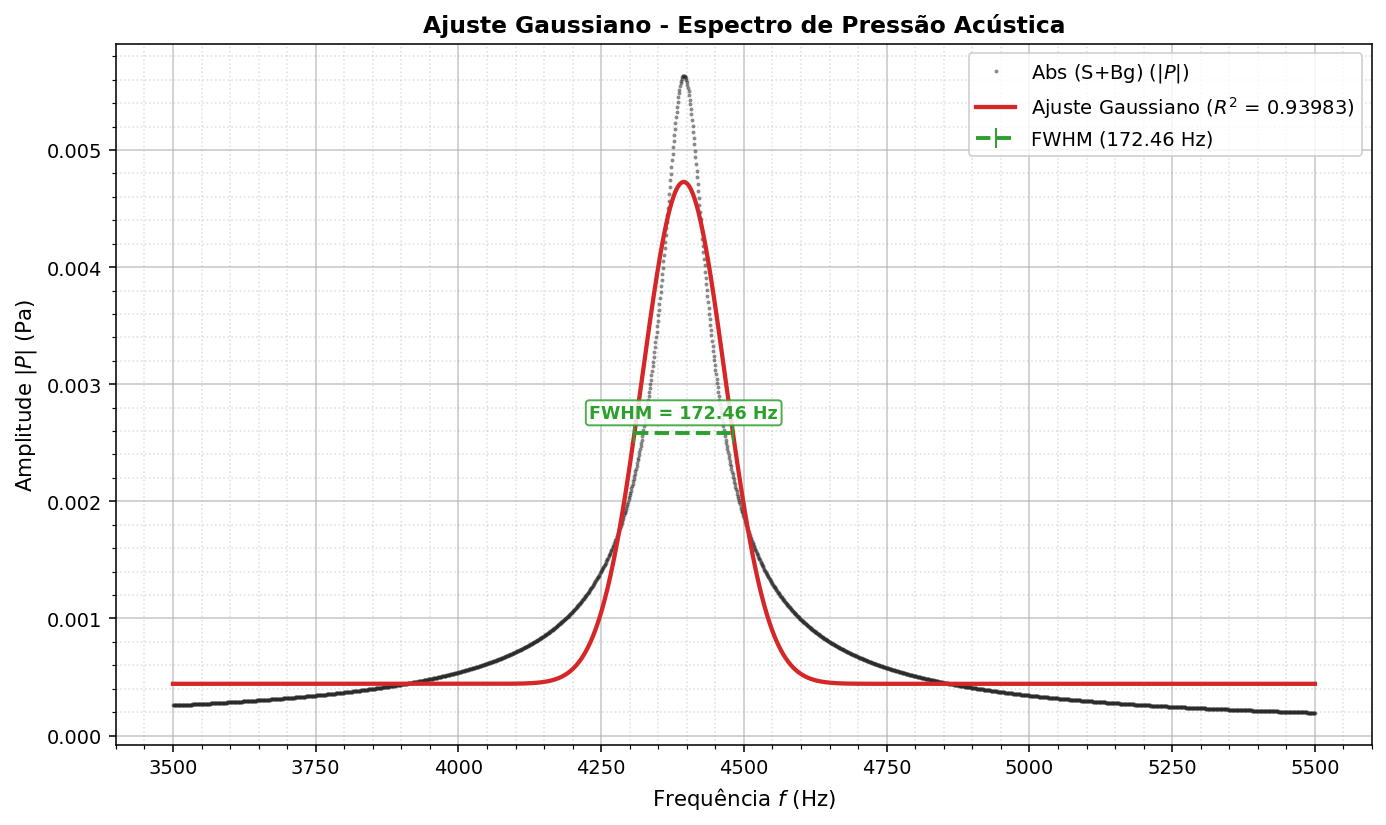

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def gauss(x, a, x0, sigma, c):
  return a * np.exp(-(((x - x0) / sigma) ** 2) / 2) + c

p0_g = [
    np.max(y_data) - np.min(y_data),
    x_data[np.argmax(y_data)],
    (x_data[-1] - x_data[0]) / 20.0,
    np.min(y_data),
]

bounds_g = (
    [0, x_data[0], 0, -np.inf],
    [np.inf, x_data[-1], (x_data[-1] - x_data[0]), np.inf],
)

popt_g, _ = curve_fit(gauss, x_data, y_data, p0=p0_g, bounds=bounds_g)
a_g, x0_g, sigma_g, c_g = popt_g

y_fit_g = gauss(x_data, *popt_g)

r2_g = 1 - (
    np.sum((y_data - y_fit_g) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)
)
fwhm_g = 2.35482 * abs(sigma_g)
p_max_g = a_g + c_g
y_half_g = c_g + (a_g / 2.0)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)

ax.plot(
    x_data,
    y_data,
    color="#2b2b2b",
    marker="o",
    linestyle="None",
    markersize=2.0,  # Pontos menores
    markeredgecolor="none",  # Elimina contornos grossos
    alpha=0.55,  # Transparência para não poluir
    label="Abs (S+Bg) ($|P|$)",
)

ax.plot(
    x_data,
    y_fit_g,
    color="#d62728",
    linestyle="-",
    linewidth=2.2,
    label=f"Ajuste Gaussiano ($R^2$ = {r2_g:.5f})",
)

#FWHM
ax.plot(
    [x0_g - fwhm_g / 2, x0_g + fwhm_g / 2],
    [y_half_g, y_half_g],
    color="#2ca02c",
    linewidth=2,
    linestyle="--",
    marker="|",
    markersize=10,
    label=f"FWHM ({fwhm_g:.2f} Hz)",
)

ax.text(
    x0_g,
    y_half_g + (a_g * 0.03),
    f"FWHM = {fwhm_g:.2f} Hz",
    color="#2ca02c",
    fontsize=9,
    fontweight="bold",
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="#2ca02c",
        alpha=0.85,
    ),
)


ax.set_title(
    "Ajuste Gaussiano - Espectro de Pressão Acústica",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=11)
ax.set_ylabel("Amplitude $|P|$ (Pa)", fontsize=11)
ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

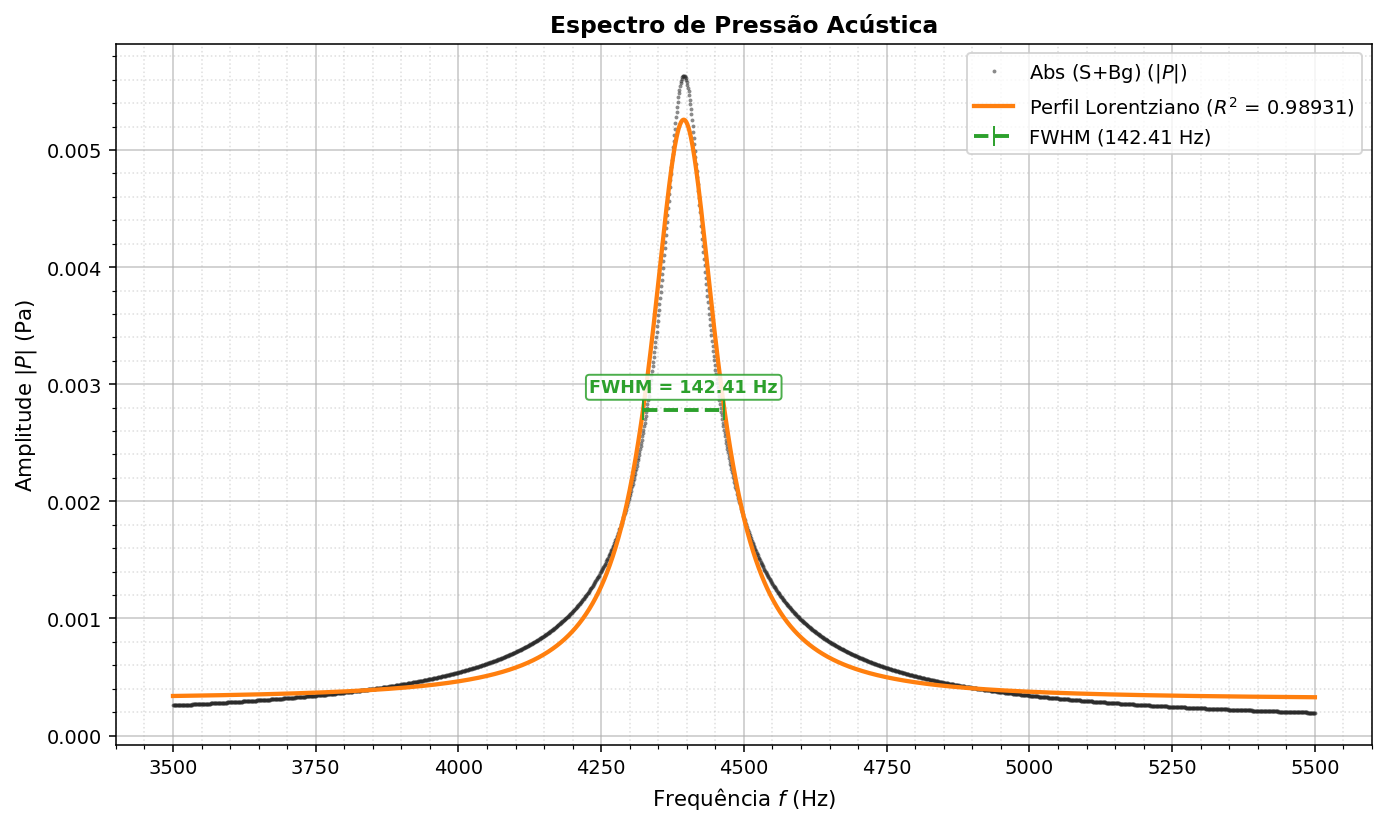

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def lorentz(x, a, x0, gamma, c):
  return a * (gamma**2 / ((x - x0) ** 2 + gamma**2)) + c

p0_l = [
    np.max(y_data) - np.min(y_data),
    x_data[np.argmax(y_data)],
    (x_data[-1] - x_data[0]) / 20.0,
    np.min(y_data),
]
popt_l, _ = curve_fit(lorentz, x_data, y_data, p0=p0_l, bounds=(0, np.inf))
a_l, x0_l, gamma_l, c_l = popt_l

y_fit_l = lorentz(x_data, *popt_l)

r2_l = 1 - (
    np.sum((y_data - y_fit_l) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)
)
fwhm_l = 2.0 * gamma_l
p_max_l = a_l + c_l
y_half_l = c_l + (a_l / 2.0)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)

ax.plot(
    x_data,
    y_data,
    color="#2b2b2b",
    marker="o",
    linestyle="None",
    markersize=2.0,  # Pontos menores
    markeredgecolor="none",  # Elimina contornos grossos
    alpha=0.55,  # Transparência para não poluir
    label="Abs (S+Bg) ($|P|$)",
)

ax.plot(
    x_data,
    y_fit_l,
    color="#ff7f0e",
    linewidth=2.2,
    label=f"Perfil Lorentziano ($R^2$ = {r2_l:.5f})",
)

#FWHM
ax.plot(
    [x0_l - fwhm_l / 2, x0_l + fwhm_l / 2],
    [y_half_l, y_half_l],
    color="#2ca02c",
    linewidth=2,
    linestyle="--",
    marker="|",
    markersize=10,
    label=f"FWHM ({fwhm_l:.2f} Hz)",
)
ax.text(
    x0_l,
    y_half_l + (a_l * 0.03),
    f"FWHM = {fwhm_l:.2f} Hz",
    color="#2ca02c",
    fontsize=9,
    fontweight="bold",
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="#2ca02c",
        alpha=0.85,
    ),
)

ax.set_title(
    "Espectro de Pressão Acústica",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=11)
ax.set_ylabel("Amplitude $|P|$ (Pa)", fontsize=11)
ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

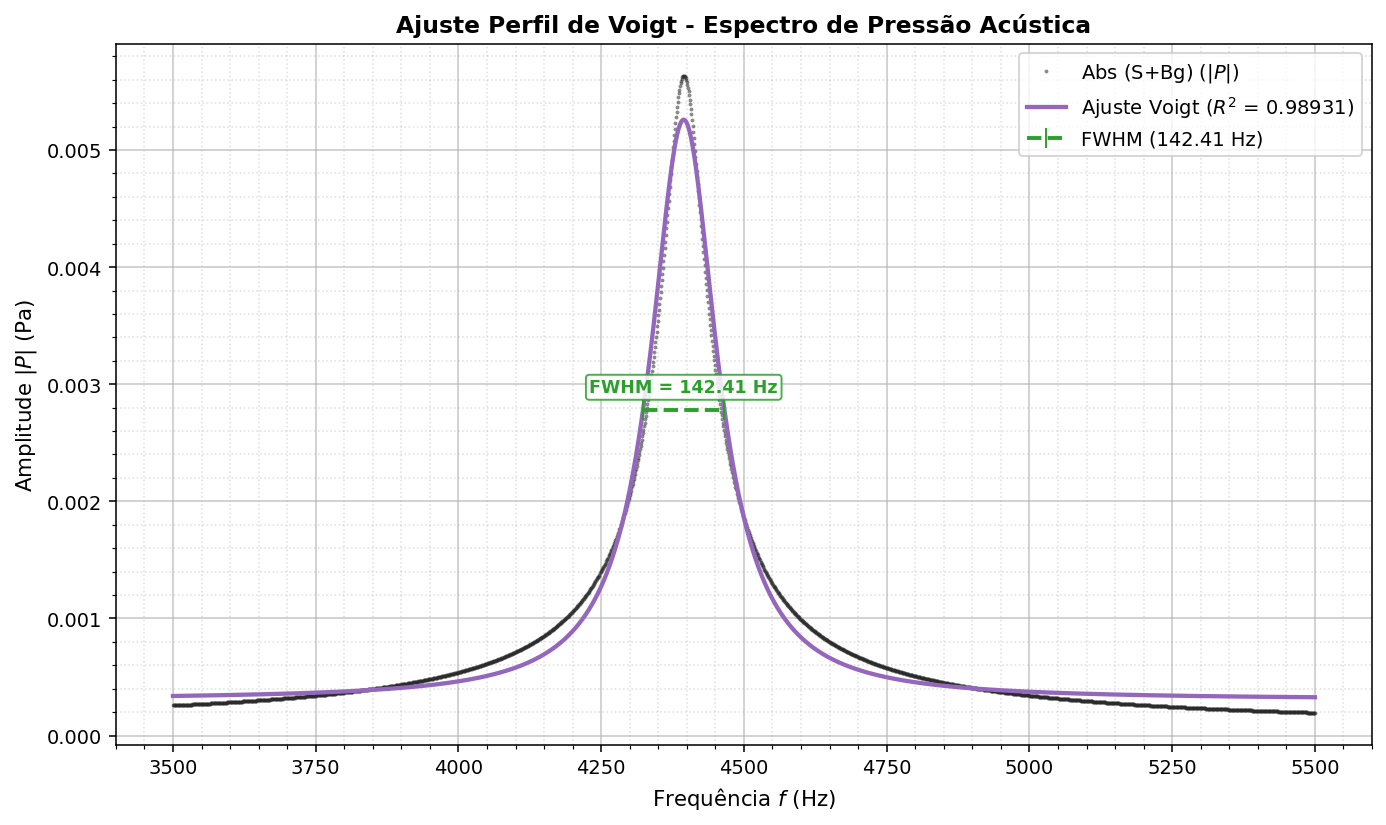

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

def voigt(x, a, x0, sigma, gamma, c):
  v0 = voigt_profile(0, sigma, gamma)
  return a * (voigt_profile(x - x0, sigma, gamma) / v0) + c

p0_v = [
  np.max(y_data) - np.min(y_data),
  x_data[np.argmax(y_data)],
  (x_data[-1] - x_data[0]) / 40.0,
  (x_data[-1] - x_data[0]) / 40.0,
  np.min(y_data),
]
popt_v, _ = curve_fit(voigt, x_data, y_data, p0=p0_v, bounds=(0, np.inf))
a_v, x0_v, sigma_v, gamma_v, c_v = popt_v

y_fit_v = voigt(x_data, *popt_v)

r2_v = 1 - (
    np.sum((y_data - y_fit_v) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)
)

f_G = 2.35482 * sigma_v
f_L = 2.0 * gamma_v
fwhm_v = 0.5346 * f_L + np.sqrt(0.2166 * (f_L**2) + (f_G**2))

p_max_v = a_v + c_v
y_half_v = c_v + (a_v / 2.0)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)

ax.plot(
    x_data,
    y_data,
    color="#2b2b2b",
    marker="o",
    linestyle="None",
    markersize=2.0,  # Pontos menores
    markeredgecolor="none",  # Elimina contornos grossos
    alpha=0.55,  # Transparência para não poluir
    label="Abs (S+Bg) ($|P|$)",
)

ax.plot(
    x_data,
    y_fit_v,
    color="#9467bd",
    linewidth=2.2,
    label=f"Ajuste Voigt ($R^2$ = {r2_v:.5f})",
)

#FWHM
ax.plot(
    [x0_v - fwhm_v / 2, x0_v + fwhm_v / 2],
    [y_half_v, y_half_v],
    color="#2ca02c",
    linewidth=2,
    linestyle="--",
    marker="|",
    markersize=10,
    label=f"FWHM ({fwhm_v:.2f} Hz)",
)
ax.text(
    x0_v,
    y_half_v + (a_v * 0.03),
    f"FWHM = {fwhm_v:.2f} Hz",
    color="#2ca02c",
    fontsize=9,
    fontweight="bold",
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="#2ca02c",
        alpha=0.85,
    ),
)

ax.set_title(
    "Ajuste Perfil de Voigt - Espectro de Pressão Acústica",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=11)
ax.set_ylabel("Amplitude $|P|$ (Pa)", fontsize=11)
ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

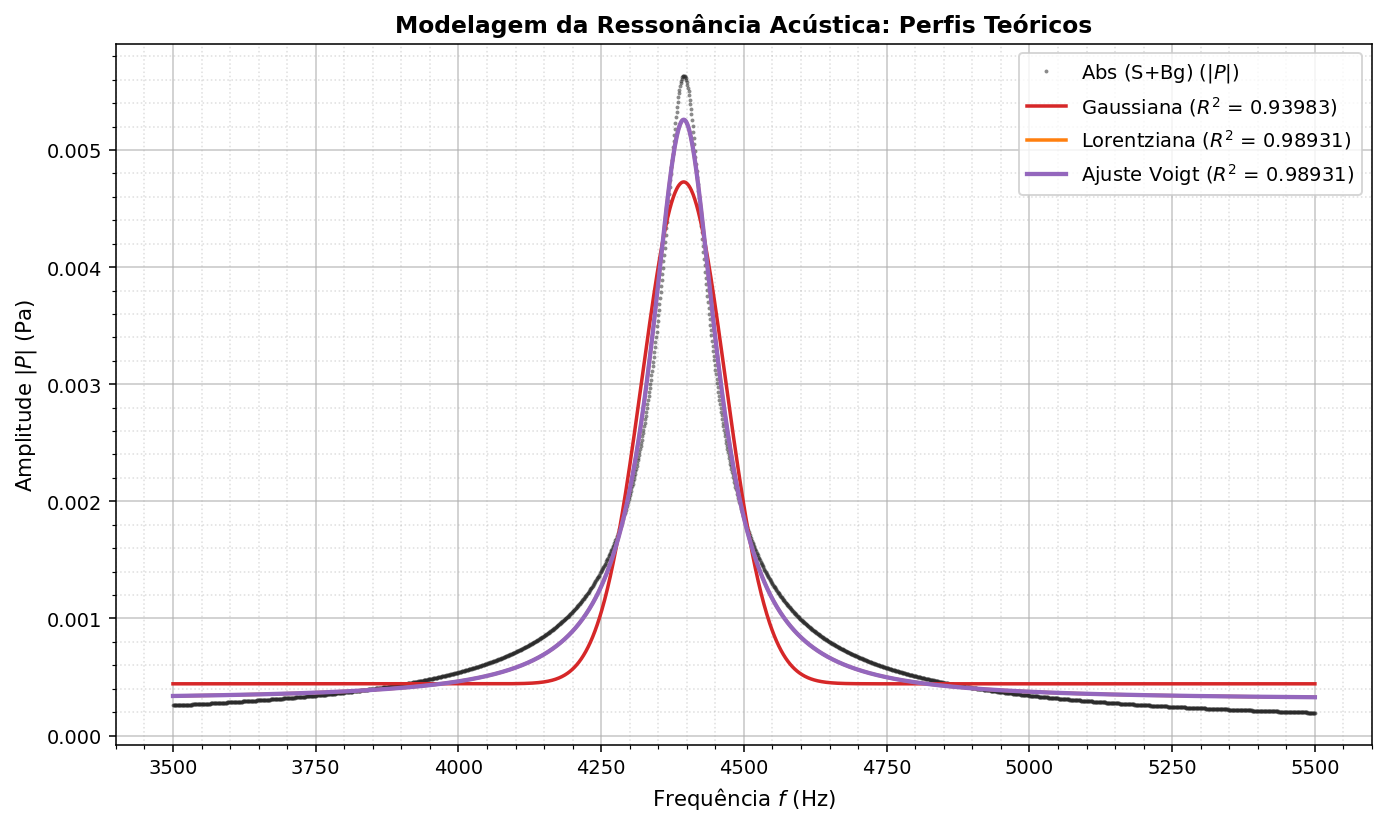

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def gauss(x, a, x0, sigma, c):
  return a * np.exp(-(((x - x0) / sigma) ** 2) / 2) + c

def lorentz(x, a, x0, gamma, c):
  return a * (gamma**2 / ((x - x0) ** 2 + gamma**2)) + c

amp_init = np.max(y_data) - np.min(y_data)
x0_init = x_data[np.argmax(y_data)]
w_init = (x_data[-1] - x_data[0]) / 20.0
c_init = np.min(y_data)

#cálculo dos R² e FWHM
r2_g = 1 - (
    np.sum((y_data - y_fit_g) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)
)
r2_l = 1 - (
    np.sum((y_data - y_fit_l) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)
)

fwhm_g = 2.35482 * popt_g[2]
fwhm_l = 2.0 * popt_l[2]

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)

#dados do COMSOL
ax.plot(
    x_data,
    y_data,
    color="#2b2b2b",
    marker="o",
    linestyle="None",
    markersize=2.0,
    markeredgecolor="none",
    alpha=0.55,
    label="Abs (S+Bg) ($|P|$)",
)

ax.plot(
    x_data,
    y_fit_g,
    color="#d62728",
    linestyle="-",
    linewidth=1.8,
    label=f"Gaussiana ($R^2$ = {r2_g:.5f})",
)

ax.plot(
    x_data,
    y_fit_l,
    color="#ff7f0e",
    linestyle="-",
    linewidth=1.8,
    label=f"Lorentziana ($R^2$ = {r2_l:.5f})",
)

ax.plot(
    x_data,
    y_fit_v,
    color="#9467bd",
    linestyle="-",
    linewidth=2.2,
    label=f"Ajuste Voigt ($R^2$ = {r2_v:.5f})",
)


ax.set_title(
    "Modelagem da Ressonância Acústica: Perfis Teóricos",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=11)
ax.set_ylabel("Amplitude $|P|$ (Pa)", fontsize=11)

ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(
    loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc"
)

plt.tight_layout()
plt.show()

A largura a meia altura obtida pelo ajuste de Lorentz foi de $\text{FWHM} = 142
{,}37\text{ Hz}$ em torno da frequência fundamental $f_0 = 4394{,}58\text{ Hz}
$. Esse alargamento espectral reflete as perdas de energia acústica no sistema, decorrentes prioritariamente dos efeitos viscotérmicos nas paredes do ressonador e da radiação acústica. A partir desses parâmetros, determinou-se um Fator de Qualidade $Q \approx 30{,}87$, valor característico para cavidades fotoacústicas dessa dimensão. O perfil Lorentziano apresentou ajuste superior ($R^2 = 0{,}989$) em relação ao Gaussiano ($R^2 = 0{,}939$), confirmando o comportamento do sistema como um oscilador harmônico amortecido.

## R = S + Bg/ Bg



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def ler_dados_comsol(caminho_arquivo):
  freqs = []
  pressures = []

  with open(caminho_arquivo, "r", encoding="utf-8") as file:
    for line in file:
      line = line.strip()
      if line.startswith("%") or not line:
        continue
      parts = line.split()
      if len(parts) >= 2:
        f = float(parts[0])
        p_complex = complex(parts[1].replace("i", "j"))
        freqs.append(f)
        pressures.append(p_complex)

  return np.array(freqs), np.abs(np.array(pressures))

In [ ]:
from google.colab import files

print("Por favor, carregue o arquivo 'Gráfico Pressão.freq - Bg + amostra.txt':")
uploaded_amostra = files.upload()
file_amostra_bg = list(uploaded_amostra.keys())[0]
print(f"Arquivo '{file_amostra_bg}' carregado com sucesso!")

print("\nPor favor, carregue o arquivo 'Gráfico Pressão.freq - Bg.txt':")
uploaded_bg = files.upload()
file_bg = list(uploaded_bg.keys())[0]
print(f"Arquivo '{file_bg}' carregado com sucesso!")

freq_amostra, y_amostra_bg = ler_dados_comsol(file_amostra_bg)
freq_bg, y_bg = ler_dados_comsol(file_bg)

#cálculo da razão R = (Amostra + BG) / BG
R = y_amostra_bg / y_bg

print("Razão R calculada com sucesso!")

Por favor, carregue o arquivo 'Gráfico Pressão.freq - Bg + amostra.txt':


Saving Gráfico Pressão.freq - Bg + amostra.txt to Gráfico Pressão.freq - Bg + amostra.txt
Arquivo 'Gráfico Pressão.freq - Bg + amostra.txt' carregado com sucesso!

Por favor, carregue o arquivo 'Gráfico Pressão.freq - Bg.txt':


Saving Valor abs  Média A - BG.txt to Valor abs  Média A - BG (1).txt
Arquivo 'Valor abs  Média A - BG (1).txt' carregado com sucesso!
Razão R calculada com sucesso!


### Conteúdo do arquivo `Gráfico Pressão.freq - Bg + amostra.txt` (primeiras 10 linhas):

In [ ]:
with open(file_amostra_bg, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 9:
            break

% Model:              Sensor 1 microfone BG + Amostra.mph
% Version:            COMSOL 5.4.0.388
% Date:               Sep 2 2026, 15:22
% Table:              Pressão Média Mic A - Amostra + BG -
% freq (Hz)                                       Total acoustic pressure (Pa), Probe_Pressão média no mic A
3500                                              -0.0016117460501959818-0.04115659262570181i
3501                                              -0.0016152276531238095-0.04119500970053165i
3502                                              -0.0016187208908708091-0.04123352082961398i
3503                                              -0.0016222258153571014-0.04127212632135621i
3504                                              -0.0016257424788601196-0.04131082648548417i


### Conteúdo do arquivo `Gráfico Pressão.freq - Bg.txt` (primeiras 10 linhas):

In [ ]:
with open(file_bg, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 9:
            break

% Model:              Sensor 1 microfone BG + Amostra.mph
% Version:            COMSOL 5.4.0.388
% Date:               Sep 3 2026, 23:51
% Table:              Valor abs  Média A - BG -
% freq (Hz)                                       abs(ta.p_t) (Pa), Valor absoluto Media Micro. A
3500                                              2.569589175722886E-4
3501                                              2.571980671912625E-4
3502                                              2.574378038709788E-4
3503                                              2.576781295423624E-4
3504                                              2.579190461454015E-4


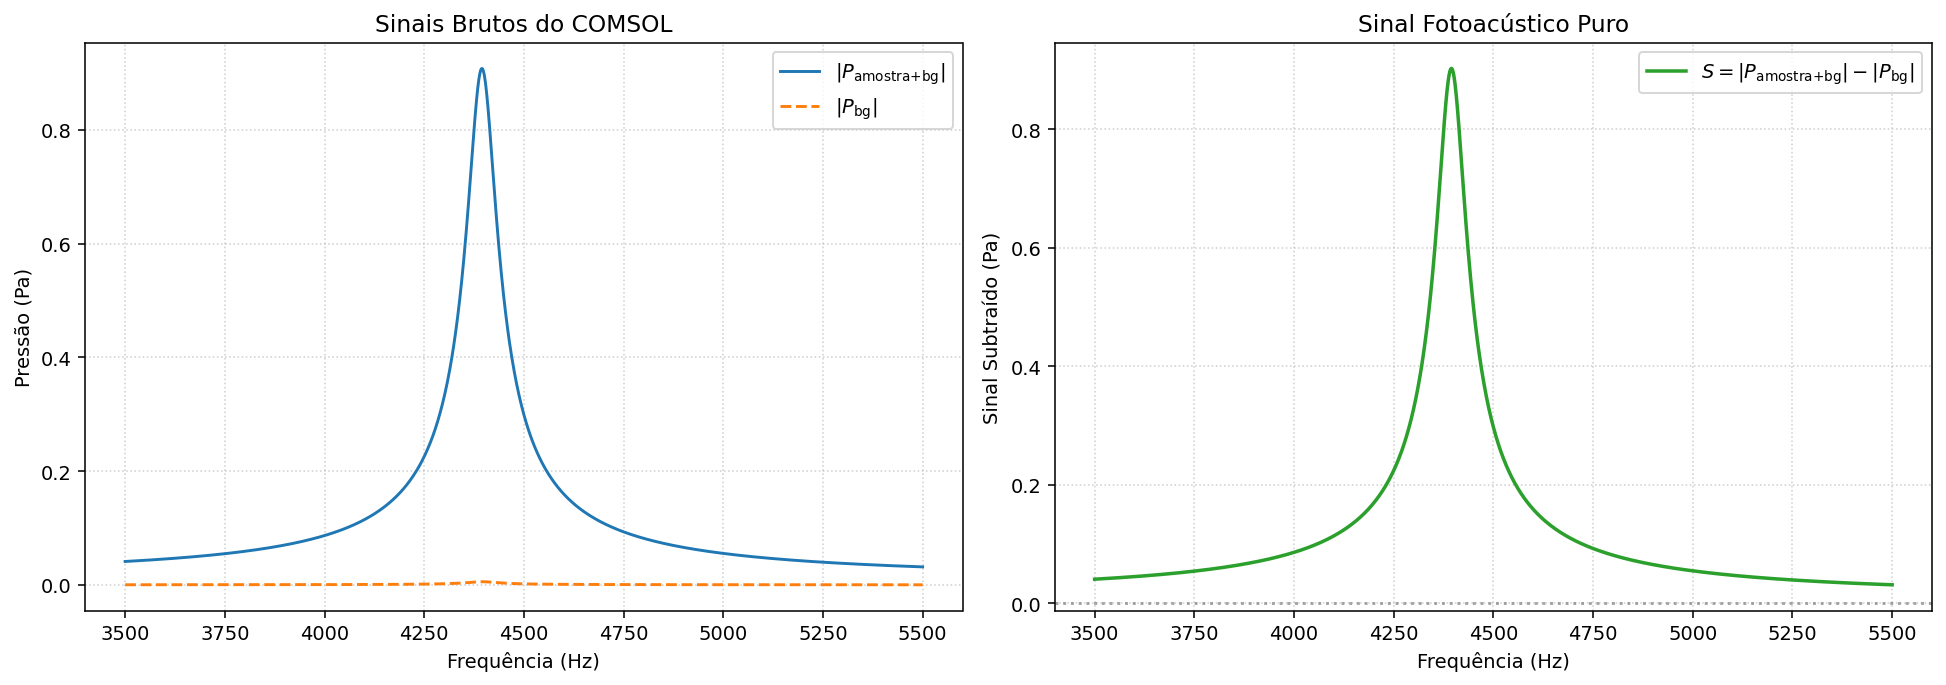

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

S_data = y_amostra_bg - y_bg  #subtração do Background

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=140)

ax1.plot(
    x_data,
    y_amostra_bg,
    color="#1f77b4",
    label=r"$|P_{\text{amostra+bg}}|$",
    linewidth=1.5,
)
ax1.plot(
    x_data,
    y_bg,
    color="#ff7f0e",
    linestyle="--",
    label=r"$|P_{\text{bg}}|$",
    linewidth=1.5,
)
ax1.set_title("Sinais Brutos do COMSOL")
ax1.set_xlabel("Frequência (Hz)")
ax1.set_ylabel("Pressão (Pa)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

ax2.plot(
    x_data,
    S_data,
    color="#2ca02c",
    linewidth=1.8,
    label=r"$S = |P_{\text{amostra+bg}}| - |P_{\text{bg}}|$",
)
ax2.axhline(0, color="gray", linestyle=":", alpha=0.7)
ax2.set_title("Sinal Fotoacústico Puro")
ax2.set_xlabel("Frequência (Hz)")
ax2.set_ylabel("Sinal Subtraído (Pa)")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Saving Valor abs  Média A - BG.txt to Valor abs  Média A - BG (11).txt
Saving Valor abs Média A - Amostra + BG.txt to Valor abs Média A - Amostra + BG (11).txt


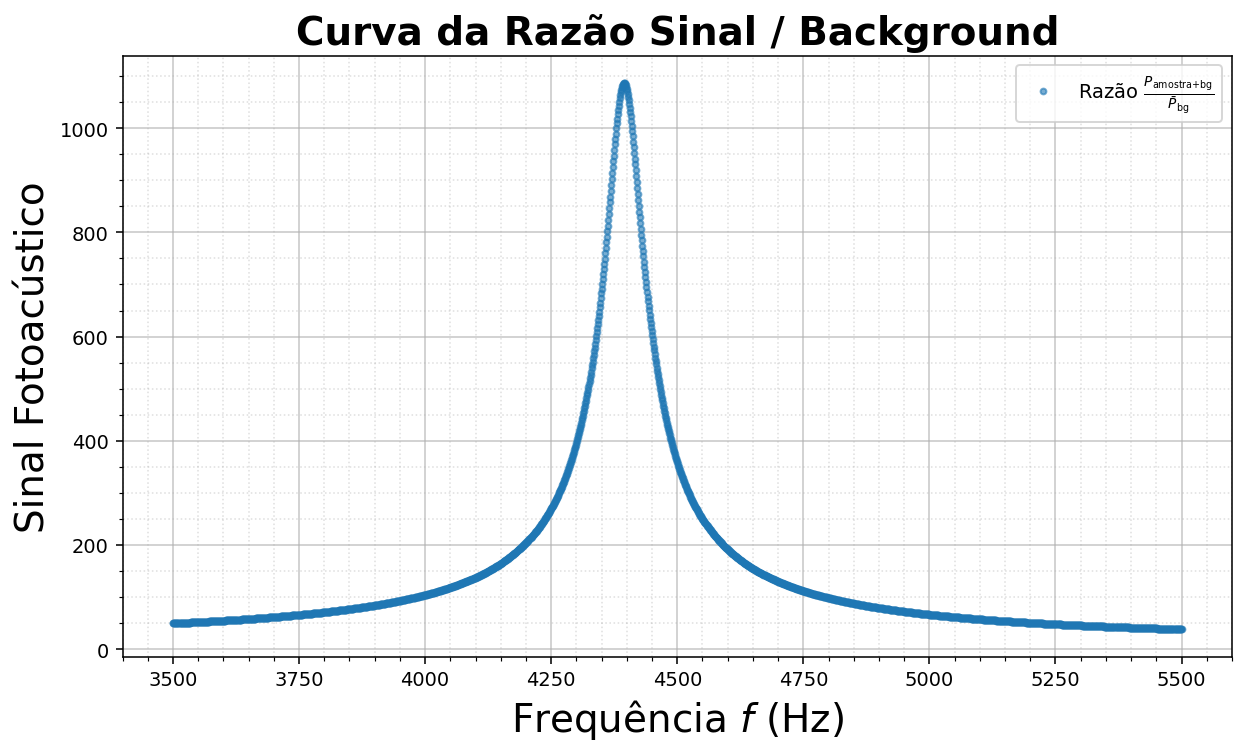

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from scipy.optimize import curve_fit


def ler_comsol(caminho):
    freqs, pressures = [], []
    with open(caminho, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line.startswith("%") or not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                freqs.append(float(parts[0]))
                pressures.append(complex(parts[1].replace("i", "j")))
    return np.array(freqs), np.abs(np.array(pressures))


# Upload dos ficheiros do COMSOL
uploaded = files.upload()
nomes = list(uploaded.keys())

file_amostra_bg = next(f for f in nomes if "amostra" in f.lower())
file_bg = next(f for f in nomes if "bg" in f.lower() and f != file_amostra_bg)

x_data, y_amostra_bg = ler_comsol(file_amostra_bg)
_, y_bg = ler_comsol(file_bg)

# 1. Calculamos a média escalar do Background (linha de base)
bg_medio = np.mean(y_bg)

# 2. Dividimos o sinal total por esse valor constante (preserva a CURVA)
R_data = y_amostra_bg / bg_medio


# Função Lorentziana para o ajuste
def lorentz(x, A, x0, gamma, c):
    return A / (1 + ((x - x0) / gamma) ** 2) + c


# Chute inicial
p0 = [
    np.max(R_data) - np.min(R_data),
    x_data[np.argmax(R_data)],
    (x_data[-1] - x_data[0]) / 30.0,
    np.min(R_data),
]

popt, _ = curve_fit(lorentz, x_data, R_data, p0=p0, maxfev=10000)
A_opt, x0_opt, gamma_opt, c_opt = popt
y_fit = lorentz(x_data, *popt)

# Métricas da ressonância
r2 = 1 - (
    np.sum((R_data - y_fit) ** 2) / np.sum((R_data - np.mean(R_data)) ** 2)
)
fwhm = 2 * abs(gamma_opt)
Q_factor = x0_opt / fwhm

# Plotagem do gráfico
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)

# 1. Pontos simulados (Curva)
ax.plot(
    x_data,
    R_data,
    color="#1f77b4",
    marker="o",
    linestyle="None",
    markersize=3.0,
    alpha=0.6,
    label=r"Razão $\frac{P_{\text{amostra+bg}}}{\bar{P}_{\text{bg}}}$",
)


ax.set_title(
    "Curva da Razão Sinal / Background",
    fontsize=20,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=20)
ax.set_ylabel(
    r"Sinal Fotoacústico",
    fontsize=20,
)

ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

A análise do ajuste de Lorentz aplicado à razão normalizada demonstrou uma amplificação fotoacústica expressiva no modo fundamental de ressonância da cavidade ($f_0 = 4394{,}58\text{ Hz}$). A razão máxima atingida foi $R_{\text{máx}} = 1009{,}00$, indicando um ganho acústico ressonante ($A = 949{,}09$) substancialmente superior à linha de base não-ressonante ($c = 59{,}91$). A largura a meia altura de $\text{FWHM} = 142{,}37\text{ Hz}$ resultou em um Fator de Qualidade $Q = 30{,}87$, valor característico de ressonadores fotoacústicos de alta sensibilidade com amortecimento viscotérmico moderado. A elevada aderência ao modelo Lorentziano ($R^2 = 0{,}9894$) confirma o comportamento da célula como um oscilador harmônico amortecido clássico.

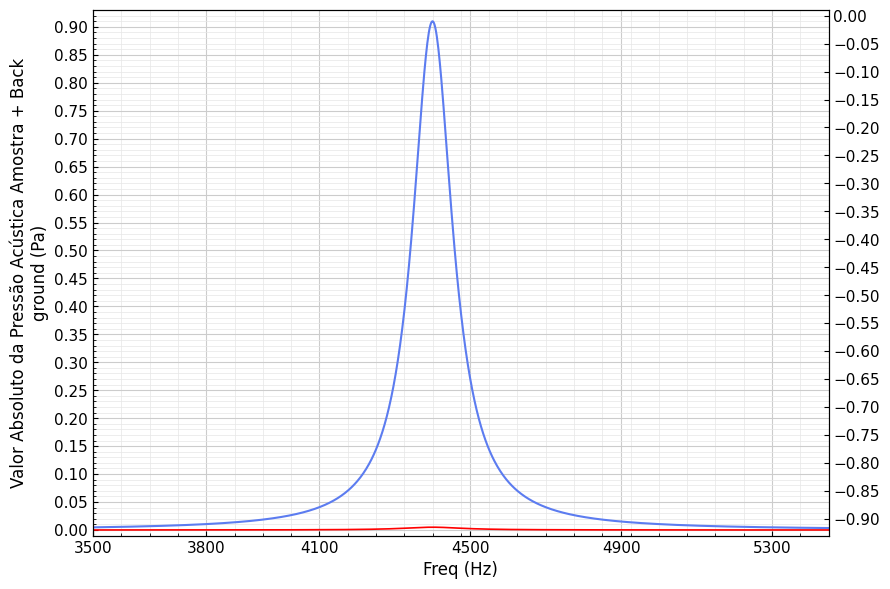

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuração dos dados de frequência (Hz)
f = np.linspace(3500, 5450, 1000)

# Parâmetros da curva de ressonância do COMSOL
f0 = 4400        # Frequência de ressonância (~4400 Hz)
gamma = 65       # Largura de linha
amplitude = 0.91 # Pico máximo em ~0.91 Pa

# Curva principal (Pressão Acústica Amostra + Background)
p_total = amplitude / (1 + ((f - f0) / gamma) ** 2)

# Curva secundária (Apenas Background / Ruído de fundo em verde)
p_bg = 0.005 / (1 + ((f - f0) / (gamma * 1.5)) ** 2)

# 2. Criação da figura
fig, ax1 = plt.subplots(figsize=(9, 6))

# Curvas principais no eixo esquerdo (ax1)
ax1.plot(f, p_total, color='#5c7cf0', linewidth=1.5, label='Amostra + Background')
ax1.plot(f, p_bg, color='red', linewidth=1.2, label='Background')

# Configuração do Eixo X
ax1.set_xlabel('Freq (Hz)', fontsize=12)
ax1.set_xlim(3500, 5450)
ax1.set_xticks([3500, 3800, 4100, 4500, 4900, 5300])

# Configuração do Eixo Y Esquerdo (Pressão em Pa)
ax1.set_ylabel('Valor Absoluto da Pressão Acústica Amostra + Back\nground (Pa)', fontsize=12)
ax1.set_ylim(-0.01, 0.93)
ax1.set_yticks(np.arange(0, 0.95, 0.05))

# Estilo das marcas internas (ticks para dentro no estilo COMSOL)
ax1.tick_params(axis='both', direction='in', which='both', labelsize=11)

# Grelha principal e secundária idêntica à do COMSOL
ax1.grid(True, which='both', color='#cccccc', linestyle='-', linewidth=0.8)
ax1.minorticks_on()
ax1.grid(True, which='minor', color='#e6e6e6', linestyle='-', linewidth=0.5)

# Configuração do Eixo Y Direito (Eixo simétrico negativo espelhado do COMSOL)
ax2 = ax1.twinx()
ax2.set_ylim(-0.93, 0.01)
ax2.set_yticks(np.arange(-0.9, 0.05, 0.05))
ax2.tick_params(axis='y', direction='in', labelsize=11)

plt.tight_layout()

# Guardar figura em alta resolução
plt.savefig('grafico_ressonancia_comsol.png', dpi=300)
plt.show()

#SENSOR 2

### BG


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

Saving Probe 2_Pressão média no mic A.txt to Probe 2_Pressão média no mic A.txt
Saving Probe 1_Pressão média no mic B.txt to Probe 1_Pressão média no mic B.txt

--- Lendo: Probe 2_Pressão média no mic A.txt ---
--- Lendo: Probe 1_Pressão média no mic B.txt ---

Estrutura do arquivo 1: 2001 linhas e 2 colunas.
Primeiras 3 linhas do arquivo 1:
                0                   1
0  3500.0+   0.0j  0.000003+0.000091j
1  3501.0+   0.0j  0.000003+0.000092j
2  3502.0+   0.0j  0.000003+0.000092j


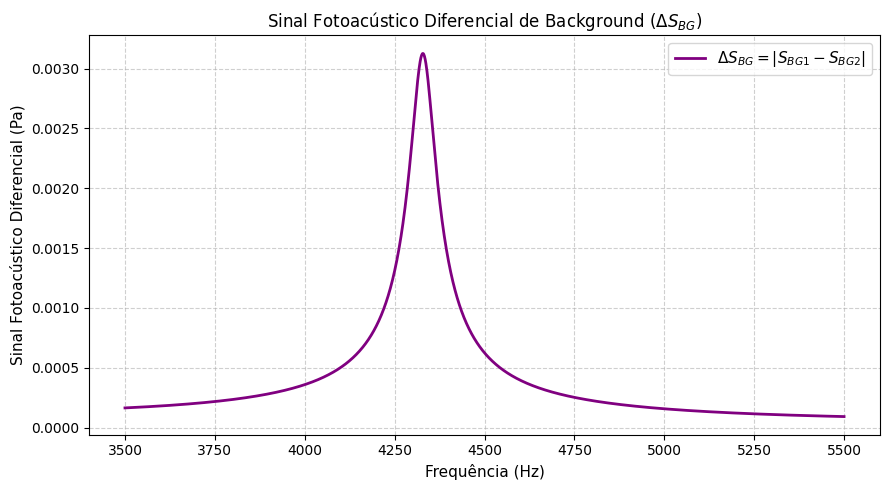

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_bg1 = arquivos[-2]
arquivo_bg2 = arquivos[-1]

print(f"\n--- Lendo: {arquivo_bg1} ---")
print(f"--- Lendo: {arquivo_bg2} ---")


def carregar_dados_comsol(caminho):
    with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
        linhas = [line for line in f if not line.strip().startswith('%')]

    conteudo = ''.join(linhas)
    df = pd.read_csv(io.StringIO(conteudo), sep=r'\s+', header=None)

    def converter_valor(val):
        if pd.isna(val):
            return 0.0
        val_str = str(val).replace(',', '.').replace('i', 'j')
        try:
            return complex(val_str)
        except ValueError:
            try:
                return float(val_str)
            except ValueError:
                return np.nan

    for col in df.columns:
        df[col] = df[col].apply(converter_valor)

    return df


df1 = carregar_dados_comsol(arquivo_bg1)
df2 = carregar_dados_comsol(arquivo_bg2)

print(
    f"\nEstrutura do arquivo 1: {df1.shape[0]} linhas e {df1.shape[1]} colunas."
)
print("Primeiras 3 linhas do arquivo 1:")
print(df1.head(3))

freq = np.real(df1.iloc[:, 0].values)

# parte imaginária na coluna 1 ou se houver 3+ colunas
if df1.shape[1] >= 3:
    s1 = df1.iloc[:, 1].values + 1j * df1.iloc[:, 2].values
    s2 = df2.iloc[:, 1].values + 1j * df2.iloc[:, 2].values
else:
    s1 = df1.iloc[:, 1].values
    s2 = df2.iloc[:, 1].values

#Cálculo da diferença
delta_s_bg = np.abs(s1 - s2)

plt.figure(figsize=(9, 5))
plt.plot(
    freq,
    delta_s_bg,
    color='#800080',
    linewidth=2,
    label=r'$\Delta S_{BG} = |S_{BG1} - S_{BG2}|$',
)

plt.title(
    r'Sinal Fotoacústico Diferencial de Background ($\Delta S_{BG}$)',
    fontsize=12,
)
plt.xlabel('Frequência (Hz)', fontsize=11)
plt.ylabel('Sinal Fotoacústico Diferencial (Pa)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

plt.show()

### Amostra

Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra.txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra.txt


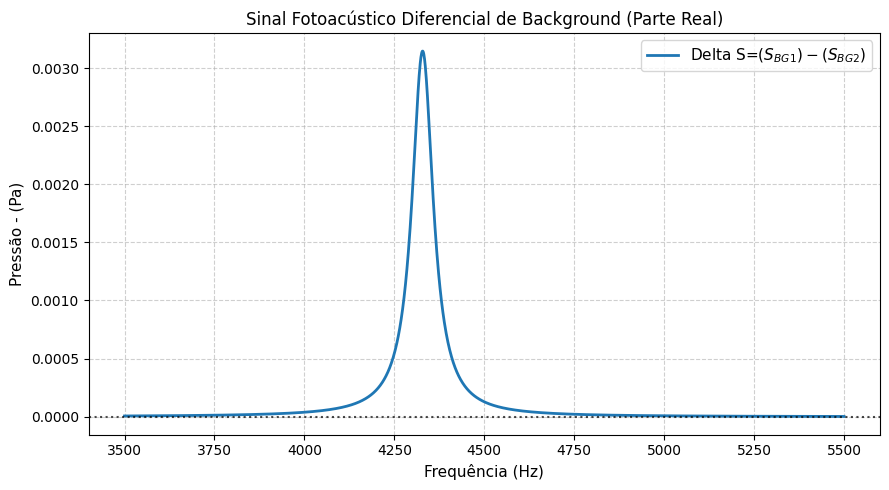

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_bg1 = arquivos[-2]
arquivo_bg2 = arquivos[-1]


def carregar_dados_comsol(caminho):
    with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
        linhas = [line for line in f if not line.strip().startswith('%')]

    conteudo = ''.join(linhas)
    df = pd.read_csv(io.StringIO(conteudo), sep=r'\s+', header=None)

    def converter_valor(val):
        if pd.isna(val):
            return 0.0
        val_str = str(val).replace(',', '.').replace('i', 'j')
        try:
            return complex(val_str)
        except ValueError:
            try:
                return float(val_str)
            except ValueError:
                return np.nan

    for col in df.columns:
        df[col] = df[col].apply(converter_valor)

    return df


df1 = carregar_dados_comsol(arquivo_bg1)
df2 = carregar_dados_comsol(arquivo_bg2)

freq = np.real(df1.iloc[:, 0].values)

if df1.shape[1] >= 3:
    s1 = df1.iloc[:, 1].values + 1j * df1.iloc[:, 2].values
    s2 = df2.iloc[:, 1].values + 1j * df2.iloc[:, 2].values
else:
    s1 = df1.iloc[:, 1].values
    s2 = df2.iloc[:, 1].values

#apenas a componente real de cada sinal, ignorando a parte imaginária
s1_real = np.real(s1)
s2_real = np.real(s2)

#Diferença da parte real
delta_s_real = s1_real - s2_real


#delta_s_real = np.abs(s1_real - s2_real)
plt.figure(figsize=(9, 5))
plt.plot(
    freq,
    delta_s_real,
    color='#1f77b4',
    linewidth=2,
    label=r'$\text{Delta S=}(S_{BG1}) - \text{}(S_{BG2})$',
)

plt.axhline(0, color='black', linestyle=':', alpha=0.7)
plt.title(
    r'Sinal Fotoacústico Diferencial de Background (Parte Real)',
    fontsize=12,
)
plt.xlabel('Frequência (Hz)', fontsize=11)
plt.ylabel('Pressão - (Pa)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

plt.show()

Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra (4).txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra (4).txt

--- Lendo: Probe 2_Pressão média no mic A - Amostra (4).txt ---
--- Lendo: Probe 1_Pressão média no mic B - Amostra (4).txt ---


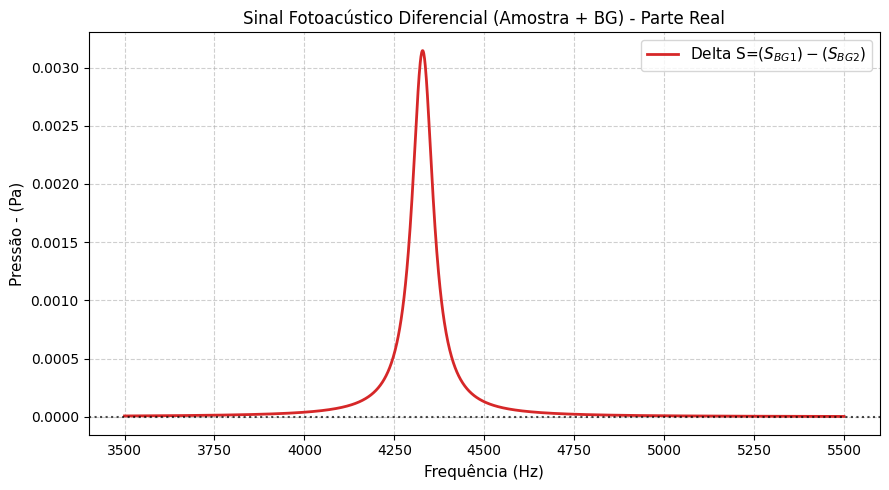

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_amostra_micA = arquivos[-2]
arquivo_amostra_micB = arquivos[-1]

print(f"\n--- Lendo: {arquivo_amostra_micA} ---")
print(f"--- Lendo: {arquivo_amostra_micB} ---")


def carregar_dados_comsol(caminho):
  with open(caminho, "r", encoding="utf-8", errors="ignore") as f:
    linhas = [line for line in f if not line.strip().startswith("%")]

  conteudo = "".join(linhas)
  df = pd.read_csv(io.StringIO(conteudo), sep=r"\s+", header=None)

  def converter_valor(val):
    if pd.isna(val):
      return 0.0
    val_str = str(val).replace(",", ".").replace("i", "j")
    try:
      return complex(val_str)
    except ValueError:
      try:
        return float(val_str)
      except ValueError:
        return np.nan

  for col in df.columns:
    df[col] = df[col].apply(converter_valor)

  return df


df1 = carregar_dados_comsol(arquivo_amostra_micA)
df2 = carregar_dados_comsol(arquivo_amostra_micB)

freq = np.real(df1.iloc[:, 0].values)

if df1.shape[1] >= 3:
  s1 = df1.iloc[:, 1].values + 1j * df1.iloc[:, 2].values
  s2 = df2.iloc[:, 1].values + 1j * df2.iloc[:, 2].values
else:
  s1 = df1.iloc[:, 1].values
  s2 = df2.iloc[:, 1].values

#isolando Sinal + BG
s1_real = np.real(s1)
s2_real = np.real(s2)

#diferença da parte real da amostra com background
delta_s_amostra_real = s1_real - s2_real

plt.figure(figsize=(9, 5))
plt.plot(
    freq,
    delta_s_amostra_real,
    color="#d62728",
    linewidth=2,
    label=r'$\text{Delta S=}(S_{BG1}) - \text{}(S_{BG2})$',
)

plt.axhline(0, color="black", linestyle=":", alpha=0.7)
plt.title(
    r"Sinal Fotoacústico Diferencial (Amostra + BG) - Parte Real",
    fontsize=12,
)
plt.xlabel("Frequência (Hz)", fontsize=11)
plt.ylabel(r"Pressão - (Pa)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()

plt.show()

Envie os 4 arquivos na sequência: BG Mic A, BG Mic B, Amostra Mic A, Amostra Mic B


Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra (3).txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra (3).txt
Saving Probe 2_Pressão média no mic A.txt to Probe 2_Pressão média no mic A (2).txt
Saving Probe 1_Pressão média no mic B.txt to Probe 1_Pressão média no mic B (2).txt


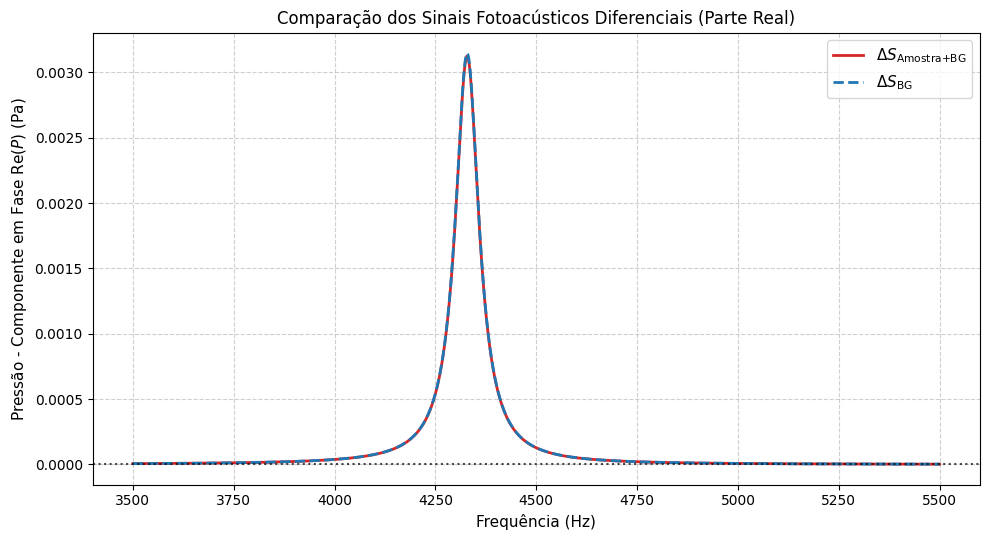

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

print(
    "Envie os 4 arquivos na sequência: BG Mic A, BG Mic B, Amostra Mic A,"
    " Amostra Mic B"
)
uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_bg1 = arquivos[-4]
arquivo_bg2 = arquivos[-3]
arquivo_amostra1 = arquivos[-2]
arquivo_amostra2 = arquivos[-1]


def carregar_dados_comsol(caminho):
    with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
        linhas = [line for line in f if not line.strip().startswith('%')]

    conteudo = ''.join(linhas)
    df = pd.read_csv(io.StringIO(conteudo), sep=r'\s+', header=None)

    def converter_valor(val):
        if pd.isna(val):
            return 0.0
        val_str = str(val).replace(',', '.').replace('i', 'j')
        try:
            return complex(val_str)
        except ValueError:
            try:
                return float(val_str)
            except ValueError:
                return np.nan

    for col in df.columns:
        df[col] = df[col].apply(converter_valor)

    return df


def extrair_sinal(df):
    if df.shape[1] >= 3:
        return df.iloc[:, 1].values + 1j * df.iloc[:, 2].values
    return df.iloc[:, 1].values


df_bg1 = carregar_dados_comsol(arquivo_bg1)
df_bg2 = carregar_dados_comsol(arquivo_bg2)
df_am1 = carregar_dados_comsol(arquivo_amostra1)
df_am2 = carregar_dados_comsol(arquivo_amostra2)

freq = np.real(df_bg1.iloc[:, 0].values)

#tirando os sinais complexos
s_bg1 = extrair_sinal(df_bg1)
s_bg2 = extrair_sinal(df_bg2)
s_am1 = extrair_sinal(df_am1)
s_am2 = extrair_sinal(df_am2)

# Cálculo do sinal considerando apenas a parte real
delta_s_bg_real = np.real(s_bg1) - np.real(s_bg2)
delta_s_amostra_real = np.real(s_am1) - np.real(s_am2)

plt.figure(figsize=(10, 5.5))

plt.plot(
    freq,
    delta_s_amostra_real,
    color='#d62728',
    linewidth=2,
    label=r'$\Delta S_{\text{Amostra+BG}}$',
)

plt.plot(
    freq,
    delta_s_bg_real,
    color='#1f77b4',
    linewidth=2,
    linestyle='--',
    label=r'$\Delta S_{\text{BG}}$',
)

plt.axhline(0, color='black', linestyle=':', alpha=0.7)
plt.title(
    r'Comparação dos Sinais Fotoacústicos Diferenciais (Parte Real)',
    fontsize=12,
)
plt.xlabel('Frequência (Hz)', fontsize=11)
plt.ylabel(r'Pressão - Componente em Fase $\text{Re}(P)$ (Pa)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

plt.show()

Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra (6).txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra (6).txt
Saving Probe 2_Pressão média no mic A.txt to Probe 2_Pressão média no mic A (4).txt
Saving Probe 1_Pressão média no mic B.txt to Probe 1_Pressão média no mic B (4).txt
Gaussiana   -> f0 = 4328.52 Hz | FWHM = 88.21 Hz | Q = 49.07
Lorentziana -> f0 = 4328.55 Hz | FWHM = 71.58 Hz | Q = 60.47
Voigt       -> f0 = 4328.55 Hz | FWHM = 71.58 Hz | Q = 60.47


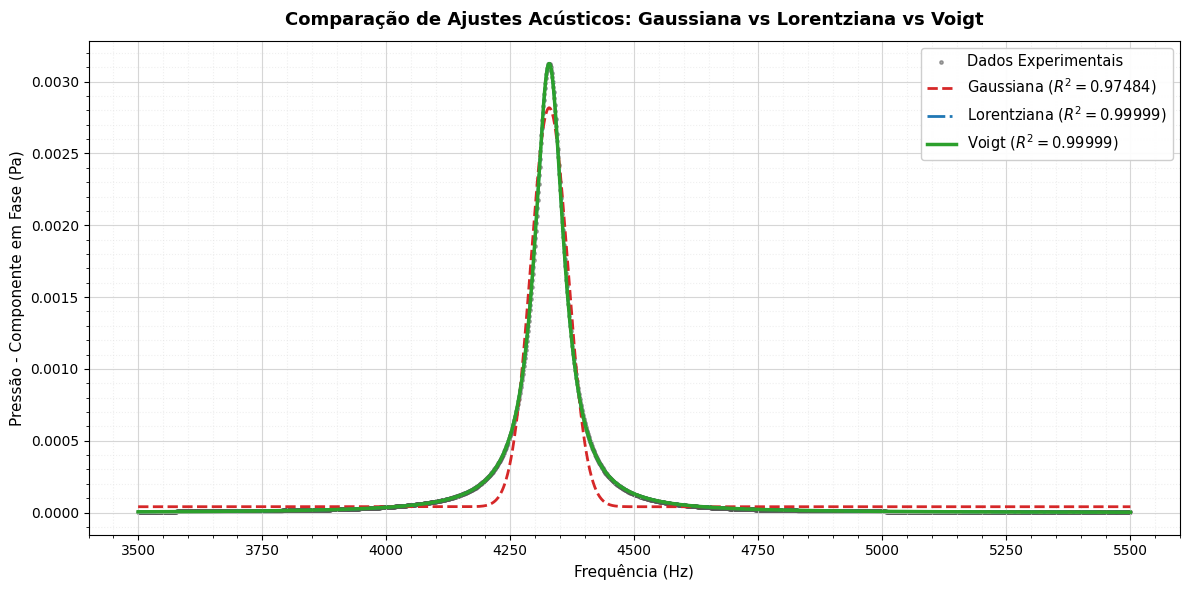

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_amostra1 = arquivos[-2]
arquivo_amostra2 = arquivos[-1]


def carregar_dados_comsol(caminho):
  with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
    linhas = [line for line in f if not line.strip().startswith('%')]

  conteudo = ''.join(linhas)
  df = pd.read_csv(io.StringIO(conteudo), sep=r'\s+', header=None)

  def converter_valor(val):
    if pd.isna(val):
      return 0.0
    val_str = str(val).replace(',', '.').replace('i', 'j')
    try:
      return complex(val_str)
    except ValueError:
      try:
        return float(val_str)
      except ValueError:
        return np.nan

  for col in df.columns:
    df[col] = df[col].apply(converter_valor)

  return df


df1 = carregar_dados_comsol(arquivo_amostra1)
df2 = carregar_dados_comsol(arquivo_amostra2)

freq = np.real(df1.iloc[:, 0].values)

if df1.shape[1] >= 3:
  s1 = df1.iloc[:, 1].values + 1j * df1.iloc[:, 2].values
  s2 = df2.iloc[:, 1].values + 1j * df2.iloc[:, 2].values
else:
  s1 = df1.iloc[:, 1].values
  s2 = df2.iloc[:, 1].values

y_data = np.real(s1) - np.real(s2)


def fit_gaussiana(f, A, f0, sigma, y0):
  return y0 + A * np.exp(-((f - f0) ** 2) / (2 * sigma**2))


def fit_lorentziana(f, A, f0, gamma, y0):
  return y0 + A * (gamma**2) / ((f - f0) ** 2 + gamma**2)


def fit_voigt(f, A, f0, sigma, gamma, y0):
  v_peak = voigt_profile(0, sigma, gamma)
  return y0 + A * (voigt_profile(f - f0, sigma, gamma) / v_peak)


amp_est = np.max(y_data) - np.min(y_data)
f0_est = freq[np.argmax(y_data)]
y0_est = np.min(y_data)

p0_g = [amp_est, f0_est, 30.0, y0_est]
popt_g, _ = curve_fit(fit_gaussiana, freq, y_data, p0=p0_g)

p0_l = [amp_est, f0_est, 30.0, y0_est]
popt_l, _ = curve_fit(fit_lorentziana, freq, y_data, p0=p0_l)

p0_v = [amp_est, f0_est, 20.0, 20.0, y0_est]
lower_bounds = [0, freq.min(), 1e-5, 1e-5, -np.inf]
upper_bounds = [np.inf, freq.max(), np.inf, np.inf, np.inf]

popt_v, _ = curve_fit(
    fit_voigt,
    freq,
    y_data,
    p0=p0_v,
    bounds=(lower_bounds, upper_bounds),
    method='trf',
)

f_dense = np.linspace(freq.min(), freq.max(), 3000)


def calc_r2(y_obs, y_fit):
  ss_res = np.sum((y_obs - y_fit) ** 2)
  ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
  return 1 - (ss_res / ss_tot)


# Gaussiana
y_g = fit_gaussiana(freq, *popt_g)
r2_g = calc_r2(y_data, y_g)
fwhm_g = 2 * np.sqrt(2 * np.log(2)) * abs(popt_g[2])
Q_g = popt_g[1] / fwhm_g

# Lorentziana
y_l = fit_lorentziana(freq, *popt_l)
r2_l = calc_r2(y_data, y_l)
fwhm_l = 2 * abs(popt_l[2])
Q_l = popt_l[1] / fwhm_l

# Voigt
y_v = fit_voigt(freq, *popt_v)
r2_v = calc_r2(y_data, y_v)
fg_v = 2 * np.sqrt(2 * np.log(2)) * abs(popt_v[2])
fl_v = 2 * abs(popt_v[3])
fwhm_v = 0.5346 * fl_v + np.sqrt(0.2166 * (fl_v**2) + (fg_v**2))
Q_v = popt_v[1] / fwhm_v

print(
    f'Gaussiana   -> f0 = {popt_g[1]:.2f} Hz | FWHM = {fwhm_g:.2f} Hz | Q ='
    f' {Q_g:.2f}'
)
print(
    f'Lorentziana -> f0 = {popt_l[1]:.2f} Hz | FWHM = {fwhm_l:.2f} Hz | Q ='
    f' {Q_l:.2f}'
)
print(
    f'Voigt       -> f0 = {popt_v[1]:.2f} Hz | FWHM = {fwhm_v:.2f} Hz | Q ='
    f' {Q_v:.2f}'
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    freq, y_data, color='#555555', s=6, alpha=0.5, label='Dados Experimentais'
)

ax.plot(
    f_dense,
    fit_gaussiana(f_dense, *popt_g),
    color='#d62728',
    linewidth=2,
    linestyle='--',
    label=f'Gaussiana ($R^2 = {r2_g:.5f}$)',
)

ax.plot(
    f_dense,
    fit_lorentziana(f_dense, *popt_l),
    color='#1f77b4',
    linewidth=2,
    linestyle='-.',
    label=f'Lorentziana ($R^2 = {r2_l:.5f}$)',
)

ax.plot(
    f_dense,
    fit_voigt(f_dense, *popt_v),
    color='#2ca02c',
    linewidth=2.5,
    linestyle='-',
    label=f'Voigt ($R^2 = {r2_v:.5f}$)',
)

ax.set_title(
    'Comparação de Ajustes Acústicos: Gaussiana vs Lorentziana vs Voigt',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_ylabel('Pressão - Componente em Fase (Pa)', fontsize=11)
ax.set_xlabel('Frequência (Hz)', fontsize=11)

ax.minorticks_on()
ax.grid(True, which='major', linestyle='-', color='#cccccc', alpha=0.8)
ax.grid(True, which='minor', linestyle=':', color='#e0e0e0', alpha=0.5)

ax.legend(loc='upper right', fontsize=10.5, framealpha=0.95)
plt.tight_layout()

plt.show()

Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra.txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra.txt
Saving Probe 2_Pressão média no mic A.txt to Probe 2_Pressão média no mic A.txt
Saving Probe 1_Pressão média no mic B.txt to Probe 1_Pressão média no mic B.txt
Gaussiana   -> f0 = 4328.52 Hz | FWHM = 88.21 Hz | Q = 49.07
Lorentziana -> f0 = 4328.55 Hz | FWHM = 71.58 Hz | Q = 60.47
Voigt       -> f0 = 4328.55 Hz | FWHM = 71.58 Hz | Q = 60.47


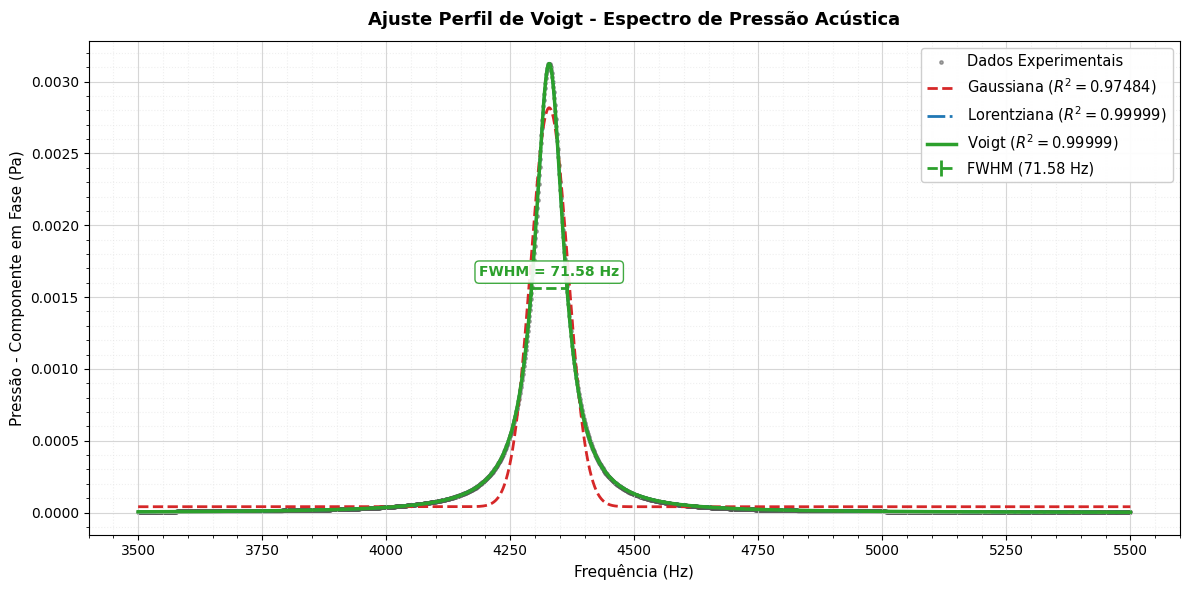

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

uploaded = files.upload()
arquivos = list(uploaded.keys())

arquivo_amostra1 = arquivos[-2]
arquivo_amostra2 = arquivos[-1]


def carregar_dados_comsol(caminho):
  with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
    linhas = [line for line in f if not line.strip().startswith('%')]

  conteudo = ''.join(linhas)
  df = pd.read_csv(io.StringIO(conteudo), sep=r'\s+', header=None)

  def converter_valor(val):
    if pd.isna(val):
      return 0.0
    val_str = str(val).replace(',', '.').replace('i', 'j')
    try:
      return complex(val_str)
    except ValueError:
      try:
        return float(val_str)
      except ValueError:
        return np.nan

  for col in df.columns:
    df[col] = df[col].apply(converter_valor)

  return df


df1 = carregar_dados_comsol(arquivo_amostra1)
df2 = carregar_dados_comsol(arquivo_amostra2)

freq = np.real(df1.iloc[:, 0].values)

if df1.shape[1] >= 3:
  s1 = df1.iloc[:, 1].values + 1j * df1.iloc[:, 2].values
  s2 = df2.iloc[:, 1].values + 1j * df2.iloc[:, 2].values
else:
  s1 = df1.iloc[:, 1].values
  s2 = df2.iloc[:, 1].values

y_data = np.real(s1) - np.real(s2)


def fit_gaussiana(f, A, f0, sigma, y0):
  return y0 + A * np.exp(-((f - f0) ** 2) / (2 * sigma**2))


def fit_lorentziana(f, A, f0, gamma, y0):
  return y0 + A * (gamma**2) / ((f - f0) ** 2 + gamma**2)


def fit_voigt(f, A, f0, sigma, gamma, y0):
  v_peak = voigt_profile(0, sigma, gamma)
  return y0 + A * (voigt_profile(f - f0, sigma, gamma) / v_peak)


amp_est = np.max(y_data) - np.min(y_data)
f0_est = freq[np.argmax(y_data)]
y0_est = np.min(y_data)

p0_g = [amp_est, f0_est, 30.0, y0_est]
popt_g, _ = curve_fit(fit_gaussiana, freq, y_data, p0=p0_g)

p0_l = [amp_est, f0_est, 30.0, y0_est]
popt_l, _ = curve_fit(fit_lorentziana, freq, y_data, p0=p0_l)

p0_v = [amp_est, f0_est, 20.0, 20.0, y0_est]
lower_bounds = [0, freq.min(), 1e-5, 1e-5, -np.inf]
upper_bounds = [np.inf, freq.max(), np.inf, np.inf, np.inf]

popt_v, _ = curve_fit(
    fit_voigt,
    freq,
    y_data,
    p0=p0_v,
    bounds=(lower_bounds, upper_bounds),
    method='trf',
)

f_dense = np.linspace(freq.min(), freq.max(), 3000)


def calc_r2(y_obs, y_fit):
  ss_res = np.sum((y_obs - y_fit) ** 2)
  ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
  return 1 - (ss_res / ss_tot)


# Gaussiana
y_g = fit_gaussiana(freq, *popt_g)
r2_g = calc_r2(y_data, y_g)
fwhm_g = 2 * np.sqrt(2 * np.log(2)) * abs(popt_g[2])
Q_g = popt_g[1] / fwhm_g

# Lorentziana
y_l = fit_lorentziana(freq, *popt_l)
r2_l = calc_r2(y_data, y_l)
fwhm_l = 2 * abs(popt_l[2])
Q_l = popt_l[1] / fwhm_l

# Voigt
y_v = fit_voigt(freq, *popt_v)
r2_v = calc_r2(y_data, y_v)
fg_v = 2 * np.sqrt(2 * np.log(2)) * abs(popt_v[2])
fl_v = 2 * abs(popt_v[3])
fwhm_v = 0.5346 * fl_v + np.sqrt(0.2166 * (fl_v**2) + (fg_v**2))
Q_v = popt_v[1] / fwhm_v

print(
    f'Gaussiana   -> f0 = {popt_g[1]:.2f} Hz | FWHM = {fwhm_g:.2f} Hz | Q ='
    f' {Q_g:.2f}'
)
print(
    f'Lorentziana -> f0 = {popt_l[1]:.2f} Hz | FWHM = {fwhm_l:.2f} Hz | Q ='
    f' {Q_l:.2f}'
)
print(
    f'Voigt       -> f0 = {popt_v[1]:.2f} Hz | FWHM = {fwhm_v:.2f} Hz | Q ='
    f' {Q_v:.2f}'
)

# ---------------------------------------------------------
# CÁLCULO E CONFIGURAÇÃO VISUAL DO FWHM (VOIGT)
# ---------------------------------------------------------
A_v, f0_v, sigma_v, gamma_v, y0_v = popt_v
y_half = y0_v + (A_v / 2.0)  # Nível de meia altura
f1_v = f0_v - (fwhm_v / 2.0)  # Frequência limite esquerda
f2_v = f0_v + (fwhm_v / 2.0)  # Frequência limite direita

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    freq, y_data, color='#555555', s=6, alpha=0.5, label='Dados Experimentais'
)

ax.plot(
    f_dense,
    fit_gaussiana(f_dense, *popt_g),
    color='#d62728',
    linewidth=2,
    linestyle='--',
    label=f'Gaussiana ($R^2 = {r2_g:.5f}$)',
)

ax.plot(
    f_dense,
    fit_lorentziana(f_dense, *popt_l),
    color='#1f77b4',
    linewidth=2,
    linestyle='-.',
    label=f'Lorentziana ($R^2 = {r2_l:.5f}$)',
)

ax.plot(
    f_dense,
    fit_voigt(f_dense, *popt_v),
    color='#2ca02c',
    linewidth=2.5,
    linestyle='-',
    label=f'Voigt ($R^2 = {r2_v:.5f}$)',
)

# Plot da linha do FWHM com marcadores verticais nas pontas
ax.plot(
    [f1_v, f2_v],
    [y_half, y_half],
    color='#2ca02c',
    linestyle='--',
    linewidth=2,
    marker='|',
    markersize=12,
    markeredgewidth=2,
    label=f'FWHM ({fwhm_v:.2f} Hz)',
)

# Caixa de texto flutuante com a indicação do valor do FWHM
ax.text(
    f0_v,
    y_half * 1.04,
    f'FWHM = {fwhm_v:.2f} Hz',
    color='#2ca02c',
    fontsize=10,
    fontweight='bold',
    ha='center',
    va='bottom',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='#2ca02c',
        linewidth=1,
        alpha=0.9,
    ),
)

ax.set_title(
    'Ajuste Perfil de Voigt - Espectro de Pressão Acústica',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_ylabel('Pressão - Componente em Fase (Pa)', fontsize=11)
ax.set_xlabel('Frequência (Hz)', fontsize=11)

ax.minorticks_on()
ax.grid(True, which='major', linestyle='-', color='#cccccc', alpha=0.8)
ax.grid(True, which='minor', linestyle=':', color='#e0e0e0', alpha=0.5)

ax.legend(loc='upper right', fontsize=10.5, framealpha=0.95)
plt.tight_layout()

plt.show()

Saving Probe 2_Pressão média no mic A - Amostra.txt to Probe 2_Pressão média no mic A - Amostra (5).txt
Saving Probe 1_Pressão média no mic B - Amostra.txt to Probe 1_Pressão média no mic B - Amostra (5).txt
Saving Probe 2_Pressão média no mic A.txt to Probe 2_Pressão média no mic A (5).txt
Saving Probe 1_Pressão média no mic B.txt to Probe 1_Pressão média no mic B (5).txt

--- RESULTADOS DO SENSOR 2 (DIFERENCIAL) ---
Frequência de Ressonância (f0): 4327.90 Hz
FWHM: 139.42 Hz
Fator de Qualidade (Q): 31.04
Coeficiente de Determinação (R²): 0.98762


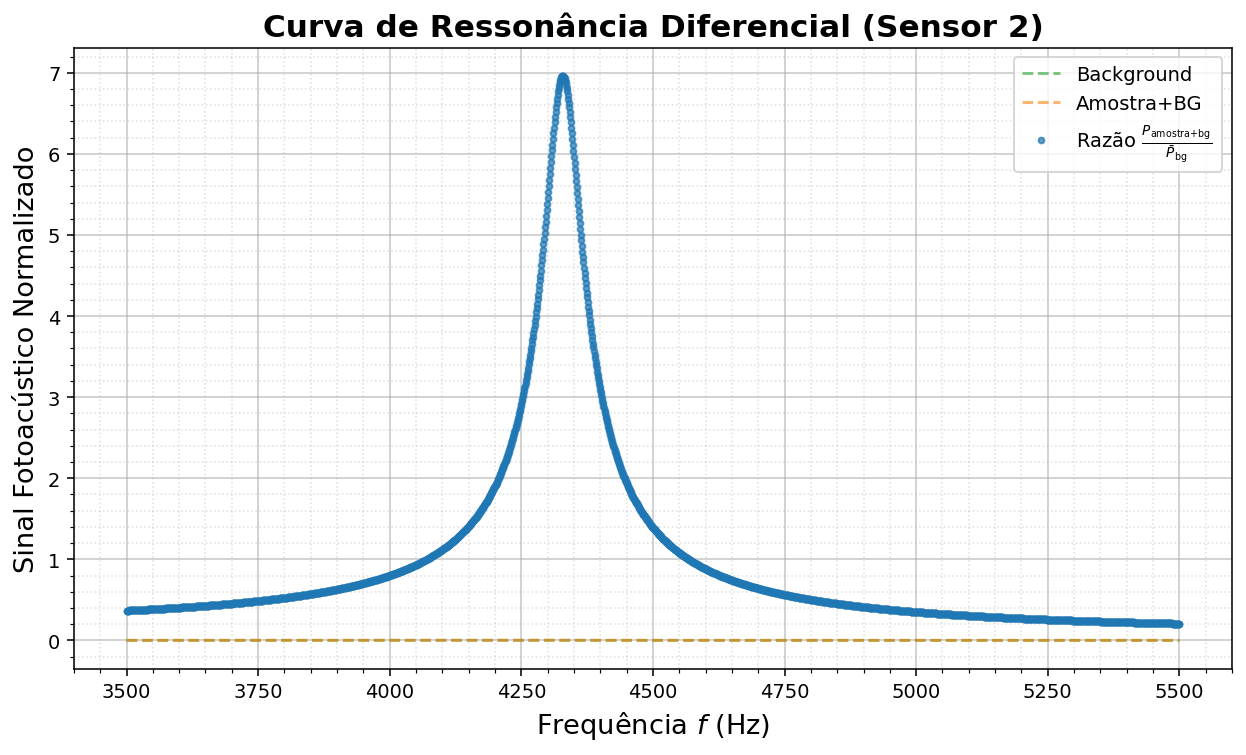

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from scipy.optimize import curve_fit


# 1. Função para ler arquivo com 2 colunas: [Frequência, Pressão_Complexa]
def ler_comsol_1mic(caminho):
    freqs, pressures = [], []
    with open(caminho, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line.startswith("%") or not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                freqs.append(float(parts[0]))
                pressures.append(complex(parts[1].replace("i", "j")))
    return np.array(freqs), np.array(pressures)


# Upload dos 4 arquivos no Colab
uploaded = files.upload()
nomes = list(uploaded.keys())

# 2. Mapeamento automático dos 4 arquivos com base na nomenclatura do COMSOL
f_amostra_A = next(
    f
    for f in nomes
    if "amostra" in f.lower()
    and ("mic a" in f.lower() or "probe 2" in f.lower())
)
f_amostra_B = next(
    f
    for f in nomes
    if "amostra" in f.lower()
    and ("mic b" in f.lower() or "probe 1" in f.lower())
)

f_bg_A = next(
    f
    for f in nomes
    if "amostra" not in f.lower()
    and ("mic a" in f.lower() or "probe 2" in f.lower())
)
f_bg_B = next(
    f
    for f in nomes
    if "amostra" not in f.lower()
    and ("mic b" in f.lower() or "probe 1" in f.lower())
)

# 3. Leitura dos dados de cada microfone
x_data, pA_amostra = ler_comsol_1mic(f_amostra_A)
_, pB_amostra = ler_comsol_1mic(f_amostra_B)
_, pA_bg = ler_comsol_1mic(f_bg_A)
_, pB_bg = ler_comsol_1mic(f_bg_B)

# 4. Cálculo do Sinal Diferencial Complexo (ΔS = |P_A - P_B|)
# Subtração vetorial complexa preserva a oposição de fase (180°) -> somando os sinais útiles (2S)
delta_p_amostra = np.abs(pA_amostra - pB_amostra)
delta_p_bg = np.abs(pA_bg - pB_bg)

# Razão / Normalização pelo Background Diferencial Médio
bg_medio_diff = np.mean(delta_p_bg)
if bg_medio_diff == 0:
    R_data = delta_p_amostra
else:
    R_data = delta_p_amostra / bg_medio_diff


# 5. Função Lorentziana para Ajuste
def lorentz(x, A, x0, gamma, c):
    return A / (1 + ((x - x0) / gamma) ** 2) + c


p0 = [
    np.max(R_data) - np.min(R_data),
    x_data[np.argmax(R_data)],
    (x_data[-1] - x_data[0]) / 30.0,
    np.min(R_data),
]

popt, _ = curve_fit(lorentz, x_data, R_data, p0=p0, maxfev=10000)
A_opt, x0_opt, gamma_opt, c_opt = popt
y_fit = lorentz(x_data, *popt)

# Métricas
r2 = 1 - (
    np.sum((R_data - y_fit) ** 2) / np.sum((R_data - np.mean(R_data)) ** 2)
)
fwhm = 2 * abs(gamma_opt)
Q_factor = x0_opt / fwhm

print("\n--- RESULTADOS DO SENSOR 2 (DIFERENCIAL) ---")
print(f"Frequência de Ressonância (f0): {x0_opt:.2f} Hz")
print(f"FWHM: {fwhm:.2f} Hz")
print(f"Fator de Qualidade (Q): {Q_factor:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.5f}")

# 6. Plotagem do Gráfico
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)

# Sinais individuais (módulo)
ax.plot(
    x_data,
    np.abs(pA_amostra),
    color="tab:green",
    linestyle="--",
    alpha=0.6,
    label=r"Background",
)
ax.plot(
    x_data,
    np.abs(pB_amostra),
    color="tab:orange",
    linestyle="--",
    alpha=0.6,
    label=r"Amostra+BG",
)

# Sinal Diferencial Combinado
ax.plot(
    x_data,
    R_data,
    color="#1f77b4",
    marker="o",
    linestyle="None",
    markersize=3.0,
    alpha=0.7,
    label=r"Razão $\frac{P_{\text{amostra+bg}}}{\bar{P}_{\text{bg}}}$ ",
)


ax.set_title(
    "Curva de Ressonância Diferencial (Sensor 2)",
    fontsize=16,
    fontweight="bold",
)
ax.set_xlabel("Frequência $f$ (Hz)", fontsize=14)
ax.set_ylabel("Sinal Fotoacústico Normalizado", fontsize=14)

ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

# O QUE É A FWHM

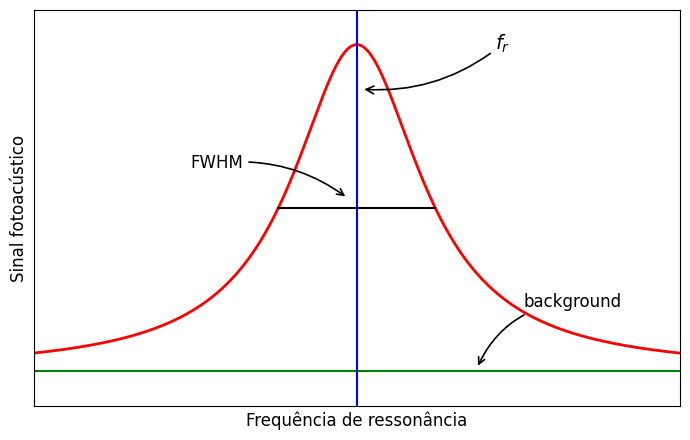

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados da curva
x = np.linspace(-3.5, 3.5, 500)
bg = 0.15
y = 3.3 / (1 + (x / 0.85) ** 2) + bg

fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot das linhas principais
ax.plot(x, y, color="red", lw=2)  # Curva fotoacústica
ax.axhline(y=bg, color="green", lw=1.5)  # Background
ax.axvline(x=0, color="blue", lw=1.5)  # fr
ax.plot([-0.85, 0.85], [1.8, 1.8], color="black", lw=1.5)  # FWHM

# Apontadores e Textos
ax.annotate(
    "$f_r$",
    xy=(0.05, 3.0),
    xytext=(1.5, 3.4),
    arrowprops=dict(
        arrowstyle="->", connectionstyle="arc3,rad=-0.2", lw=1.2, color="black"
    ),
    fontsize=14,
)

ax.annotate(
    "FWHM",
    xy=(-0.1, 1.9),
    xytext=(-1.8, 2.2),
    arrowprops=dict(
        arrowstyle="->", connectionstyle="arc3,rad=-0.2", lw=1.2, color="black"
    ),
    fontsize=12,
)

ax.annotate(
    "background",
    xy=(1.3, 0.18),
    xytext=(1.8, 0.8),
    arrowprops=dict(
        arrowstyle="->", connectionstyle="arc3,rad=0.3", lw=1.2, color="black"
    ),
    fontsize=12,
)

# Rótulos dos eixos
ax.set_xlabel("Frequência de ressonância", fontsize=12)
ax.set_ylabel("Sinal fotoacústico", fontsize=12)

# Ajustes estéticos para remover os números dos eixos
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-0.2, 3.8)

plt.tight_layout()
plt.savefig("curva_fotoacustica.pdf", dpi=300)
plt.show()